# Exploratory Data Analysis (EDA) & Model Prototyping - Disaster Tweets

This notebook performs an exploratory data analysis on the Kaggle *Natural Language Processing with Disaster Tweets* dataset, builds a baseline ML classifier, and prototypes a deep-learning RoBERTa model.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")

## 1. Load the Dataset

In [2]:
train_df = pd.read_csv('nlp-getting-started/train.csv')
print(f"Dataset Shape: {train_df.shape}")
train_df.head()

Dataset Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 2. Missing Values Analysis

In [3]:
missing_values = train_df.isnull().sum()
missing_percent = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage (%)': missing_percent})
missing_df

,Missing Count,Percentage (%)
id,0,0.000000
keyword,61,0.801261
location,2533,33.272035
text,0,0.000000
target,0,0.000000


## 3. Class Distribution

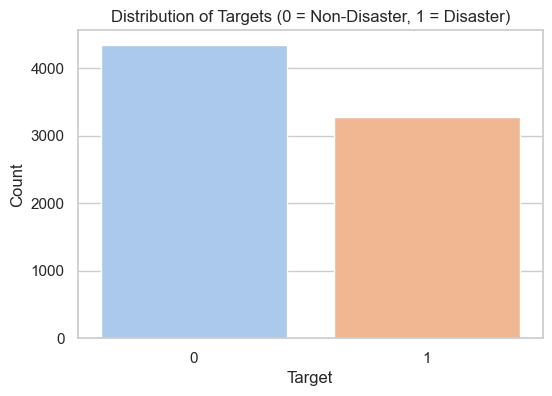

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train_df, hue='target', palette='pastel', legend=False)
plt.title('Distribution of Targets (0 = Non-Disaster, 1 = Disaster)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## 4. Text Length and Word Count Analysis

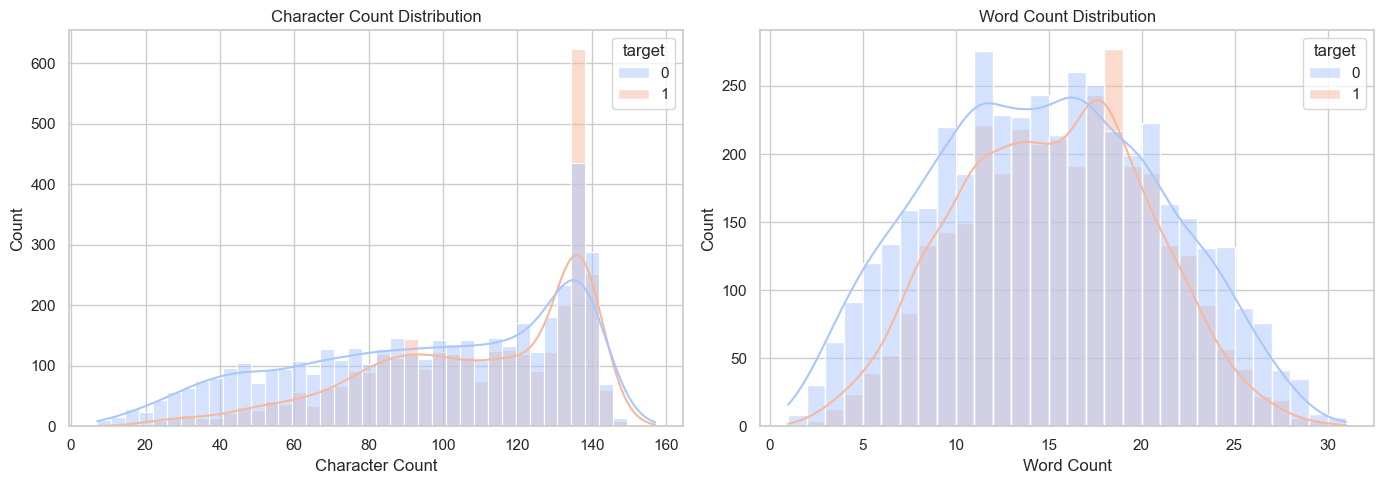

In [5]:
train_df['char_count'] = train_df['text'].apply(len)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=train_df, x='char_count', hue='target', kde=True, bins=40, ax=axes[0], palette='coolwarm')
axes[0].set_title('Character Count Distribution')
axes[0].set_xlabel('Character Count')

sns.histplot(data=train_df, x='word_count', hue='target', kde=True, bins=30, ax=axes[1], palette='coolwarm')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

## 5. Feature Engineering & Feature Correlation

We engineer a few text-derived metadata features to see if they correlate with the disaster `target`:
- `has_url`: Does the tweet mention a URL (http/https)?
- `has_mention`: Does the tweet mention another user (@)?
- `has_hashtag`: Does the tweet contain a hashtag (#)?
- `is_keyword_missing`: Is the keyword missing?

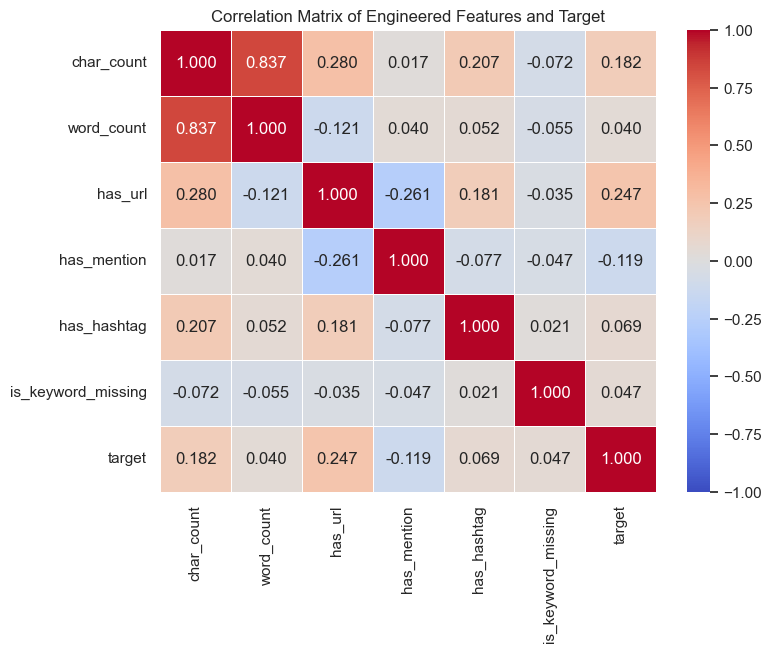

In [6]:
# Engineering metadata features
train_df['has_url'] = train_df['text'].apply(lambda x: 1 if re.search(r'https?:\/\/\S+|www\.\S+', x) else 0)
train_df['has_mention'] = train_df['text'].apply(lambda x: 1 if re.search(r'@\w+', x) else 0)
train_df['has_hashtag'] = train_df['text'].apply(lambda x: 1 if re.search(r'#\w+', x) else 0)
train_df['is_keyword_missing'] = train_df['keyword'].isnull().astype(int)

# Select numeric columns for correlation
numeric_cols = ['char_count', 'word_count', 'has_url', 'has_mention', 'has_hashtag', 'is_keyword_missing', 'target']
corr_matrix = train_df[numeric_cols].corr()

# Plotting the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Engineered Features and Target')
plt.show()

## 6. Most Common Keywords

/var/folders/t8/ck7x549546b459855c3l7hn00000gn/T/ipykernel_4208/527918927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


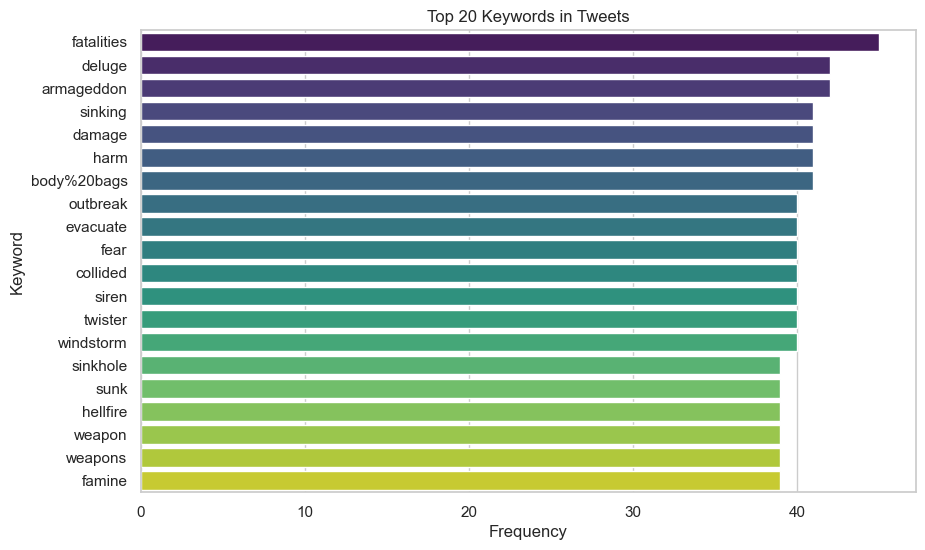

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(
    y=train_df['keyword'].value_counts().head(20).index, 
    x=train_df['keyword'].value_counts().head(20).values, 
    palette='viridis'
)
plt.title('Top 20 Keywords in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.show()

## 7. Hashtags Analysis

/var/folders/t8/ck7x549546b459855c3l7hn00000gn/T/ipykernel_4208/2189558213.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in dis_counter], y=[val[0] for val in dis_counter], ax=axes[0], palette='Reds_r')
/var/folders/t8/ck7x549546b459855c3l7hn00000gn/T/ipykernel_4208/2189558213.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val[1] for val in non_counter], y=[val[0] for val in non_counter], ax=axes[1], palette='Blues_r')


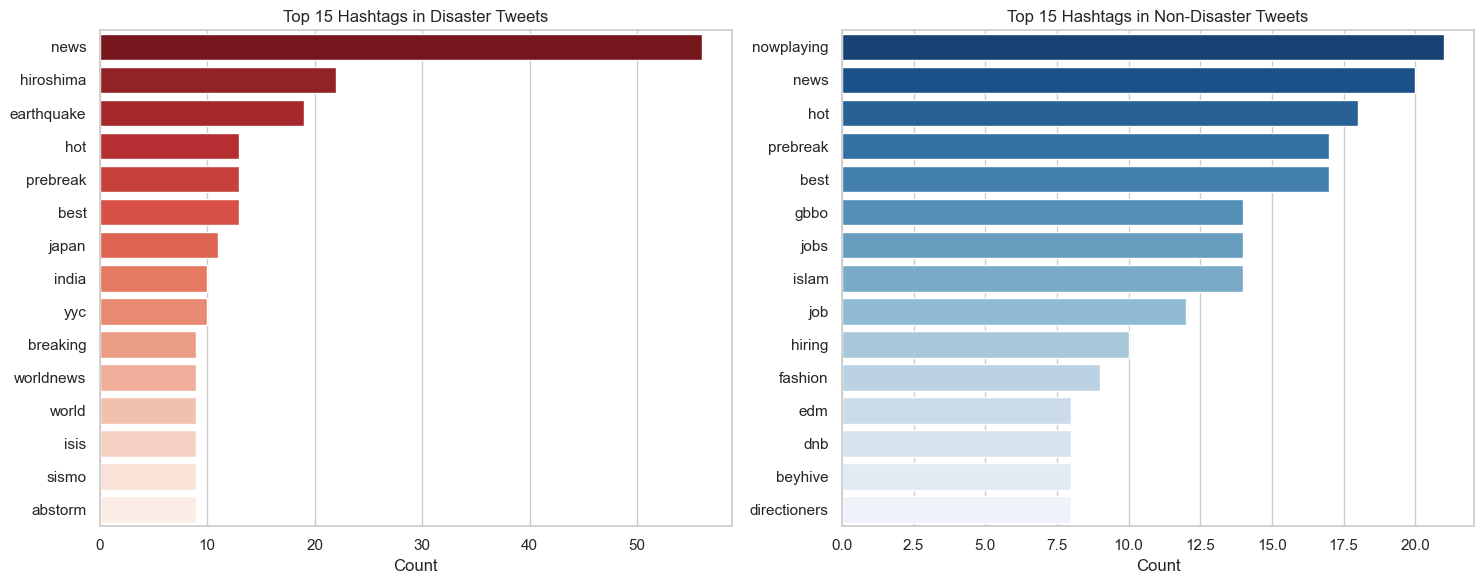

In [8]:
def get_hashtags(text):
    return re.findall(r'#(\w+)', text.lower())

disaster_hashtags = []
non_disaster_hashtags = []

for idx, row in train_df.iterrows():
    tags = get_hashtags(row['text'])
    if row['target'] == 1:
        disaster_hashtags.extend(tags)
    else:
        non_disaster_hashtags.extend(tags)

dis_counter = Counter(disaster_hashtags).most_common(15)
non_counter = Counter(non_disaster_hashtags).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=[val[1] for val in dis_counter], y=[val[0] for val in dis_counter], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Hashtags in Disaster Tweets')
axes[0].set_xlabel('Count')

sns.barplot(x=[val[1] for val in non_counter], y=[val[0] for val in non_counter], ax=axes[1], palette='Blues_r')
axes[1].set_title('Top 15 Hashtags in Non-Disaster Tweets')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 8. Classical ML Baseline Model (TF-IDF + Logistic Regression)

Baseline Validation Accuracy: 82.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523


Confusion Matrix:
[[783  86]
 [188 466]]


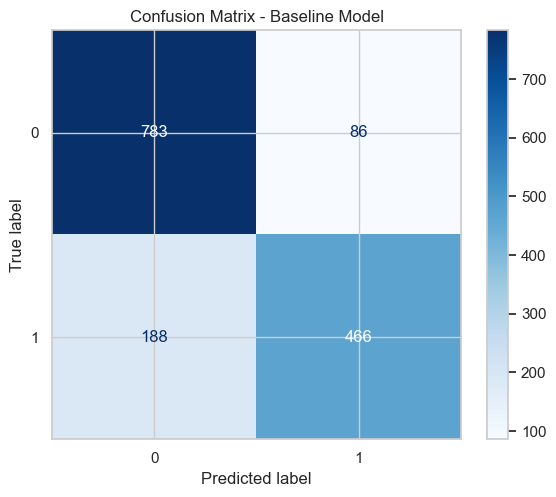

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split training data into train and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'], 
    train_df['target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=train_df['target']
)

# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

# Train a Logistic Regression model
clf = LogisticRegression(C=1.0, max_iter=1000)
clf.fit(X_train_vec, y_train)

# Evaluate predictions on validation set
y_pred = clf.predict(X_val_vec)

accuracy = accuracy_score(y_val, y_pred)
print(f"Baseline Validation Accuracy: {accuracy * 100:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.show()

### Kaggle Submission (TF-IDF + Logistic Regression)

Refit vectorizer + model on the full training set, predict on `test.csv`, write `submission.csv`.

In [10]:
test_df = pd.read_csv('nlp-getting-started/test.csv')

# Refit on ALL training data (no val split) for max signal before predicting test set
final_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_full_vec = final_vectorizer.fit_transform(train_df['text'])
X_test_vec = final_vectorizer.transform(test_df['text'])

final_clf = LogisticRegression(C=1.0, max_iter=1000)
final_clf.fit(X_full_vec, train_df['target'])

test_preds = final_clf.predict(X_test_vec)

submission = pd.DataFrame({'id': test_df['id'], 'target': test_preds})
submission.to_csv('submission.csv', index=False)
print(f"Wrote submission.csv with shape {submission.shape}")
submission.head()

Wrote submission.csv with shape (3263, 2)


,id,target
0,0,1
1,2,1
2,3,1
3,9,0
4,11,1


## 9. Local LLM Baseline (Ollama - Qwen2.5-1.5B)

As a lightweight local-LLM comparison point, we few-shot prompt a locally-hosted **Qwen2.5-1.5B** model (via [Ollama](https://ollama.com)) to classify the same 50-tweet sample and report accuracy, confusion matrix, and classification report.

In [11]:
import sys
import subprocess

try:
    import ollama
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ollama"])
    import ollama

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Same 50-tweet sample for direct comparison against the other models
sample_df = train_df.sample(50, random_state=42).copy()

system_prompt = (
    "You are an automated disaster classifier. Classify the tweet as 1 (real disaster, accident, or hazard) or 0 (not a disaster, including figurative speech, jokes, or movie talk). "
    "Analyze the keyword and the tweet text carefully. Respond with exactly one character: '0' or '1'."
)

predictions = []
actuals = list(sample_df['target'])
tweets = list(sample_df['text'])
keywords = list(sample_df['keyword'])

print("Starting few-shot evaluation on 50 sample tweets using qwen2.5:1.5b...")

for idx, tweet in enumerate(tweets):
    kw_str = str(keywords[idx]) if pd.notnull(keywords[idx]) else "None"

    few_shot_prompt = (
        "Here are examples of how to classify:\n\n"
        "Keyword: fatalities\n"
        "Tweet: \"As of the 6-month mark there were a total of 662 fatalities.\"\n"
        "Class: 1\n\n"
        "Keyword: tragedy\n"
        "Tweet: \"Can't find my ariana grande shirt this is a fucking tragedy...\"\n"
        "Class: 0\n\n"
        "Keyword: sinking\n"
        "Tweet: \"We walk the plank of a sinking ship...\"\n"
        "Class: 0\n\n"
        "Keyword: earthquake\n"
        "Tweet: \"Nepal earthquake 3 months on: Women fear abuse.\"\n"
        "Class: 1\n\n"
        "Now classify the following tweet:\n\n"
        f"Keyword: {kw_str}\n"
        f"Tweet: \"{tweet}\"\n"
        "Class:"
    )

    try:
        response = ollama.chat(
            model='qwen2.5:1.5b',
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': few_shot_prompt}
            ],
            options={
                'temperature': 0.0,
                'num_predict': 2
            }
        )
        pred_text = response['message']['content'].strip()

        if '1' in pred_text:
            pred = 1
        elif '0' in pred_text:
            pred = 0
        else:
            pred = 0

        predictions.append(pred)
        print(f"[{idx+1}/50] Actual: {actuals[idx]} | Pred: {pred} | Keyword: {kw_str} | Tweet: {tweet[:50]}...")
    except Exception as e:
        print(f"[{idx+1}/50] Error predicting: {e}")
        predictions.append(0)

print("\n=== FEW-SHOT EVALUATION REPORT (Qwen2.5-1.5B) ===")
print("Accuracy:", accuracy_score(actuals, predictions))

print("\nConfusion Matrix:")
cm = confusion_matrix(actuals, predictions)
print(f"True Negative (Non-Disaster correctly predicted): {cm[0][0]}")
print(f"False Positive (Non-Disaster predicted as Disaster): {cm[0][1]}")
print(f"False Negative (Disaster predicted as Non-Disaster): {cm[1][0]}")
print(f"True Positive (Disaster correctly predicted): {cm[1][1]}")
print(f"\nRaw Matrix:\n{cm}")

print("\nClassification Report:")
print(classification_report(actuals, predictions, target_names=["Non-Disaster", "Disaster"]))

Starting few-shot evaluation on 50 sample tweets using qwen2.5:1.5b...


[1/50] Actual: 1 | Pred: 1 | Keyword: destruction | Tweet: So you have a new weapon that can cause un-imagina...


[2/50] Actual: 0 | Pred: 1 | Keyword: deluge | Tweet: The f$&amp;@ing things I do for #GISHWHES Just got...


[3/50] Actual: 1 | Pred: 1 | Keyword: police | Tweet: DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe CoL...


[4/50] Actual: 0 | Pred: 0 | Keyword: aftershock | Tweet: Aftershock back to school kick off was great. I wa...


...

[46/50] Actual: 1 | Pred: 1 | Keyword: hurricane | Tweet: @pattonoswalt @FoxNews Wait I thought Fecal Hurric...


[47/50] Actual: 1 | Pred: 1 | Keyword: evacuate | Tweet: California wildfires force thousands to evacuate: ...


[48/50] Actual: 0 | Pred: 1 | Keyword: hijacker | Tweet: Remove the http://t.co/Xxj2B4JxRt and Linkury Brow...


[49/50] Actual: 1 | Pred: 1 | Keyword: evacuate | Tweet: myGC: Broken powerlines evacuate Gold Coast tram s...


[50/50] Actual: 1 | Pred: 0 | Keyword: weapons | Tweet: 'The Reagan Administration had arranged for Israel...

=== FEW-SHOT EVALUATION REPORT (Qwen2.5-1.5B) ===
Accuracy: 0.78

Confusion Matrix:
True Negative (Non-Disaster correctly predicted): 20
False Positive (Non-Disaster predicted as Disaster): 9
False Negative (Disaster predicted as Non-Disaster): 2
True Positive (Disaster correctly predicted): 19

Raw Matrix:
[[20  9]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

Non-Disaster       0.91      0.69      0.78        29
    Disaster       0.68      0.90      0.78        21

    accuracy                           0.78        50
   macro avg       0.79      0.80      0.78        50
weighted avg       0.81      0.78      0.78        50

